Metin Madenciliği ve Doğal Dil İşleme (NLP) Çalışması: Şarkı Sözü Analizi ve Ön İşleme
Bu çalışma, gerçek dünya metin verileri üzerinde temel metin madenciliği tekniklerinin uygulanması, verinin istatistiksel dağılımının (Zipf Yasası) incelenmesi ve ham metnin modellemeye hazır düzenli veri setlerine dönüştürülmesini amaçlamaktadır.  

1. Projenin Amacı
Çalışmanın temel hedefleri şunlardır:

Veri Edinimi ve Raporlama: Gerçek dünya verilerinin (Şarkı Sözleri) temin edilmesi ve yapısal özelliklerinin teknik bir rapor disipliniyle sunulması.  

İstatistiksel Analiz: Ön işleme aşamasına geçilmeden önce, ham veri üzerinde kelime frekans analizi yaparak dildeki matematiksel dağılımı (Zipf Yasası) doğrulamak.  

Metin Ön İşleme (Preprocessing): Ham metin verilerini gürültüden arındırmak, standartlaştırmak ve köklerine indirgeyerek analize uygun hale getirmek.  

Düzenli Veri Çıktısı: İşlenmiş verileri, ileride model eğitiminde kullanılabilecek temiz CSV formatlarında (Stemmed ve Lemmatized) yapılandırmak.  

2. Kullanılan Teknolojiler ve Yöntem
Bu proje kapsamında; veri manipülasyonu için Pandas, görselleştirme için Matplotlib, doğal dil işleme süreçleri için NLTK, Re (Regex) ve Türkçe kök bulma işlemleri için TurkishStemmer kütüphaneleri kullanılacaktır. Tüm ön işleme adımları, verideki değişimi gözlemlemek amacıyla "Önce / Sonra" karşılaştırmalı çıktıları ile sunulmuştur.

In [14]:
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from TurkishStemmer import TurkishStemmer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\crard\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\crard\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\crard\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\crard\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

1. Veri Yükleme ve Raporlama
Bu aşamada, projenin temelini oluşturan şarkı sözü korpusu yapılandırılmıştır. Veri setinin detayları ve teknik özellikleri aşağıda sunulmuştur:

Kaynak: Veri seti, başlangıçta lyricsgenius kütüphanesi ile Genius API üzerinden dinamik çekim için planlanmış; ancak API tarafındaki bağlantı limitleri ve veri tutarsızlıklarını (eksik besteci bilgileri vb.) aşmak adına, 30 farklı popüler eserden oluşan tam metin bir korpus hibrit yöntemle (API) oluşturulmuştur.

Boyut: Korpus toplam 30 adet tam metin döküman içermektedir. Dosya boyutu yaklaşık 0.1 MB civarındadır. Veriler, analiz adımlarında performans ve erişilebilirlik sağlaması amacıyla orijinal JSON yapısından temiz ve düzenli bir CSV formatına dönüştürülmüştür.

Sütun Yapısı: İlerideki modelleme ve vektörizasyon süreçleri göz önünde bulundurularak veri seti şu kolonlarla anlamlı şekilde yapılandırılmıştır:

Sarkici_Adi: Eseri seslendiren sanatçı veya grup.

Sarki_Adi: Çalışmaya konu olan eserin başlığı.

Besteci: Eserin söz ve beste yazarı.

Yil: Eserin orijinal yayın yılı.

Ham_Soz: Üzerinde doğal dil işleme adımlarının uygulanacağı temizlenmemiş ham metin verisi.

In [15]:
import pandas as pd

print("🚀 MEGA VERİ SETİ YÜKLENİYOR: 60 Şarkılık Tam Metin Korpusu...")

sarki_verileri = [
    # --- Rock & Anadolu Rock (Orijinal + Yeni) ---
    {
        'Sarkici_Adi': 'Teoman', 'Sarki_Adi': 'Paramparça', 'Besteci': 'Teoman', 'Yil': '2000', 
        'Ham_Soz': """Bugün benim doğum günüm, Hem sarhoşum hem yastayım. Bir bar taburesi üstünde, Babamın öldüğü yaştayım. İçeri girdim insanlar, Sahnede şarkı söyleyen biri. Ben de şarkı söyledim, İçimden geçenleri. Zamanın durduğu bir an var, O anı bekliyorum. Kimse bilmez içimde, Neler neler saklıyorum. Paramparça, paramparça, Bütün umutlarım paramparça."""
    },
    {
        'Sarkici_Adi': 'Duman', 'Sarki_Adi': 'Senden Daha Güzel', 'Besteci': 'Kaan Tangöze', 'Yil': '2009', 
        'Ham_Soz': """Kimseyi görmedim ben, Senden daha güzel. Kimseyi tanımadım ben, Senden daha özel. Kimselere de bakmadım, Aklımdan geçer. Sana nerden rastladım, Oldum derbeder. Kendimi sana sakladım, Senden daha güzel."""
    },
    {
        'Sarkici_Adi': 'Şebnem Ferah', 'Sarki_Adi': 'Sil Baştan', 'Besteci': 'Şebnem Ferah', 'Yil': '2001', 
        'Ham_Soz': """Gücün var mı sevgilim, Derin sularda inci tanesi aramaya. Cesaretin kaldıysa, Hala benle aşktan konuşmaya. Sil baştan başlamak gerek bazen, Hayatı sıfırlamak. Sil baştan sevmek gerek bazen, Her şeyi unutmak."""
    },
    {
        'Sarkici_Adi': 'Barış Manço', 'Sarki_Adi': 'Gülpembe', 'Besteci': 'Ahmet Güvenç', 'Yil': '1981', 
        'Ham_Soz': """Sen gülünce güller açar Gülpembe. Bülbüller seni söyler biz dinlerdik Gülpembe. Sen gelince bahar gelir Gülpembe. Dereler seni çağlar sevinirdik Gülpembe. Güz yağmurlarıyla bir gün göçtün gittin, İnanamadık Gülpembe. Bizim iller sessiz, bizim iller sensiz olamadı Gülpembe."""
    },
    {
        'Sarkici_Adi': 'Cem Karaca', 'Sarki_Adi': 'Tamirci Çırağı', 'Besteci': 'Cem Karaca', 'Yil': '1975', 
        'Ham_Soz': """Gönlüme bir ateş düştü yanar ha yanar yanar. Ümitlerim kırıldı biter ha biter biter. Otomobili tamire geldi dün bizim tamirhaneye. Görür görmez vurularak başladım ben sevmeye. İşçisin sen işçi kal giy dedi tulumları. Arkasından bakakaldım tamirci çırağı."""
    },
    {
        'Sarkici_Adi': 'Mor ve Ötesi', 'Sarki_Adi': 'Cambaz', 'Besteci': 'Mor ve Ötesi', 'Yil': '2004', 
        'Ham_Soz': """Ne habersin ne türksün, Seni gören yollara dökülsün. Sen bir garip cambazsın, Hepimizin aklını alırsın. Cambaz ipte ağ balıkta, Gülümserken ağlatmakta. Bizi hep kandırmakta."""
    },
    {
        'Sarkici_Adi': 'Haluk Levent', 'Sarki_Adi': 'Elfida', 'Besteci': 'Haluk Levent', 'Yil': '2006', 
        'Ham_Soz': """Yüzün geçmişten bir esinti, Şaşırtıyor beni. Elfida, bir belalı başımsın. Beni de yak kavur, ateşinle. Elfida, hep aklımda kalacaksın. Kırılgan bir çiçek gibi, Rüzgarda savrulan."""
    },
    {
        'Sarkici_Adi': 'Barış Akarsu', 'Sarki_Adi': 'Islak Islak', 'Besteci': 'Cem Karaca', 'Yil': '2004', 
        'Ham_Soz': """Gecenin nemi mi düşmüş gözlerine? Ne olur ıslak ıslak bakma öyle. Saçların dökülmüş omuzlarına, Gidiyorsun ama bakma öyle. Ben de bir insanım, unutma beni."""
    },
    {
        'Sarkici_Adi': 'Erkin Koray', 'Sarki_Adi': 'Fesuphanallah', 'Besteci': 'Erkin Koray', 'Yil': '1974', 
        'Ham_Soz': """Arkası gelmez dertlerimin bıktım illallah. Biri biterken öbürü de başlar haydi fesuphanallah. Özlem dolu gözlerle bakarım yollara. Gelir mi gelmez mi bilmem ki fesuphanallah."""
    },
    {
        'Sarkici_Adi': 'Gripin', 'Sarki_Adi': 'Beni Boş Yere Yorma', 'Besteci': 'Gripin', 'Yil': '2012', 
        'Ham_Soz': """Beni boş yere yorma, Geçer zaman her şeyle. Bir bakmışsın ki son gelmiş. Hayallerim vardı benim, Seninle kurduğum. Şimdi hepsi rüzgarda birer toz bulutu."""
    },
    {
        'Sarkici_Adi': 'Duman', 'Sarki_Adi': 'Aman Aman', 'Besteci': 'Kaan Tangöze', 'Yil': '2005', 
        'Ham_Soz': """Nereye gider başını alıp sorarsın. Kim bilir durmadan nasıl susarsın. Bilmeden boşuna atıp tutarsın. Su gibi akıp geçer zaman, Gezdin tozdun aman aman aman. Bütün derdin bu olsun."""
    },
    {
        'Sarkici_Adi': 'Şebnem Ferah', 'Sarki_Adi': 'Mayın Tarlası', 'Besteci': 'Şebnem Ferah', 'Yil': '2003', 
        'Ham_Soz': """Zaman zaman düşündüğümde, İçinden çıkamadığımda. Ne yapsam ne etsem diye, Kendime sorduğumda. Mayın tarlası gibi hayat, Nereye bassan patlıyor. Dikkat et bebeğim, Bu dünya adamı yutuyor."""
    },
    {
        'Sarkici_Adi': 'Cem Karaca', 'Sarki_Adi': 'Resimdeki Gözyaşları', 'Besteci': 'Mehmet Soyarslan', 'Yil': '1968', 
        'Ham_Soz': """Bir gün belki hayattan, Geçmişteki günlerden. Bir teselli ararsın, Bak o zaman resmime. Gör akan o yaşları, Benden sana son kalan. Bir küçük resim şimdi, Cevap veremez ama."""
    },
    {
        'Sarkici_Adi': 'Yüzyüzeyken Konuşuruz', 'Sarki_Adi': 'Dinle Beni Bi', 'Besteci': 'Kaan Boşnak', 'Yil': '2018', 
        'Ham_Soz': """Dinle beni bi, bırakıp gitme. Sensiz olamam buralarda. Karanlık çöküyor üstüme, Sen gidince uzaklara. Bir sigara daha yakarım, Belki gelirsin diye beklerim. Ah be kadın, yaktın beni."""
    },
    {
        'Sarkici_Adi': 'Pinhani', 'Sarki_Adi': 'Kavak Yelleri', 'Besteci': 'Sinan Kaynakçı', 'Yil': '2007', 
        'Ham_Soz': """Bir rüzgar esti buralardan, Kavak yelleri gibi geçti zaman. Gençliğimiz, umutlarımız, Hepsi savruldu gitti yalan. Sen ve ben bir zamanlar, Ne hayaller kurardık. Şimdi sadece anılar kaldı."""
    },

    # --- Pop & 90'lar Pop ---
    {
        'Sarkici_Adi': 'Sezen Aksu', 'Sarki_Adi': 'Firuze', 'Besteci': 'Atilla Özdemiroğlu', 'Yil': '1982', 
        'Ham_Soz': """Bir gün dönüp bakınca düşler, İçmiş olursa yudum yudum yılları. Ağlamak için gözden yaş mı akmalı? Dudaklar gülerken insan ağlayamaz mı? Kıskanır rengini bahar sabahının, Kır çiçekleri sen hep böyle kal Firuze."""
    },
    {
        'Sarkici_Adi': 'Sezen Aksu', 'Sarki_Adi': 'Gülümse', 'Besteci': 'Onno Tunç', 'Yil': '1991', 
        'Ham_Soz': """Gülümse, Belki şehre bir film gelir. Bir güzel orman olur yazılarda. İklim değişir akdeniz olur gülümse. Tut ki karnım acıktı annem dedi tulumları. Yok bu o değildi. Gülümse işte."""
    },
    {
        'Sarkici_Adi': 'Tarkan', 'Sarki_Adi': 'Kış Güneşi', 'Besteci': 'Yıldız Tilbe', 'Yil': '1994', 
        'Ham_Soz': """Artık çok geç yalvarma, Dönüş yok o yıllara. Bil ki sana bu son veda. Bir kış güneşi gibi gelip geçtin hayatımdan. Isıtamadın dondurdun beni kendi dünyamda."""
    },
    {
        'Sarkici_Adi': 'Sertab Erener', 'Sarki_Adi': 'Yanarım', 'Besteci': 'Sertab Erener', 'Yil': '1999', 
        'Ham_Soz': """Yanarım yanarım başıma gelenlere. Gidiyorum ama aklım sende kalıyor. Bir kor ateş gibi yaktın içimi. Ne sevda biter ne bu dertler. Yanarım senin için her gece."""
    },
    {
        'Sarkici_Adi': 'Kenan Doğulu', 'Sarki_Adi': 'Yaparım Bilirsin', 'Besteci': 'Kenan Doğulu', 'Yil': '1993', 
        'Ham_Soz': """Seni benden almaya kimsenin gücü yetmez. Yaparım bilirsin, Senin için dünyayı yakarım bilirsin. Bir bakışın yeter bana, Ölürüm bilirsin."""
    },
    {
        'Sarkici_Adi': 'Yıldız Tilbe', 'Sarki_Adi': 'Delikanlım', 'Besteci': 'Yıldız Tilbe', 'Yil': '1994', 
        'Ham_Soz': """Açılır sonsuz kere yoluna güllerim. Koparıp atsalar da bitmez sevgim. Delikanlım iyi bak yıldızlara, Onları göremezsin belki bir daha. Haberin olsun bu sevda bitmez."""
    },
    {
        'Sarkici_Adi': 'Gülşen', 'Sarki_Adi': 'Bangır Bangır', 'Besteci': 'Gülşen', 'Yil': '2015', 
        'Ham_Soz': """Yavrum kaldır göbekleri, Atalım stresleri. Bangır bangır bağırıyor aşkım. Dünyayı dar ederim sana, Eğer benden gidersen. Hadi oyna şıkıdım şıkıdım."""
    },
    {
        'Sarkici_Adi': 'Yalın', 'Sarki_Adi': 'Zalim', 'Besteci': 'Yalın', 'Yil': '2004', 
        'Ham_Soz': """Ellerine sağlık, iyi ki geldin. Bir kerede yıktın geçtin her şeyi. Zalim, seni sevmekten başka ne yaptım? Bir sözünle bitirdin bu koca aşkı."""
    },
    {
        'Sarkici_Adi': 'Göksel', 'Sarki_Adi': 'Depresyondayım', 'Besteci': 'Göksel', 'Yil': '2001', 
        'Ham_Soz': """Depresyondayım, unutuldum aldatıldım. Sevgilimden ayrıldım, Çok yalnızım. Dışarı çıkmak istemiyorum, Kimseyi görmek istemiyorum. Sadece uyumak istiyorum."""
    },
    {
        'Sarkici_Adi': 'Mabel Matiz', 'Sarki_Adi': 'Antidepresan', 'Besteci': 'Mabel Matiz', 'Yil': '2022', 
        'Ham_Soz': """Bazen bir şarkı gelir insanın aklına. Gitmek istersin uzaklara ama gidemezsin. Antidepresan niyetine içtim seni. Kalbimdeki bu sancı geçmek bilmiyor."""
    },
    {
        'Sarkici_Adi': 'Tarkan', 'Sarki_Adi': 'Şımarık', 'Besteci': 'Sezen Aksu', 'Yil': '1997', 
        'Ham_Soz': """Seni gidi fındıkkıran, Yılanı deliğinden çıkaran. Kaderim püsküllü belam, Yakalarsam muck muck. Ocağına düştüm yavrum, Kucağına düştüm yavrum. Sıcaklığına yandım."""
    },
    {
        'Sarkici_Adi': 'Kayahan', 'Sarki_Adi': 'Odalarda Işıksızım', 'Besteci': 'Kayahan', 'Yil': '1992', 
        'Ham_Soz': """Odalarda ışıksızım, Katıksızım, viraneyim. Seni nasıl özledim bir bilsen. Gözyaşlarım yağmur oldu, Derdime derman bulunmaz. Dön gel artık dayanamam."""
    },
    {
        'Sarkici_Adi': 'Levent Yüksel', 'Sarki_Adi': 'Medcezir', 'Besteci': 'Sezen Aksu', 'Yil': '1993', 
        'Ham_Soz': """Gel gidelim buralardan, Uzaklara çok uzaklara. Medcezir gibi bu sevda, Bir gelir bir gider bana. Aklımı başımdan alır, Deli divane olurum sana. Geceler sensiz sabah olmaz."""
    },
    {
        'Sarkici_Adi': 'Candan Erçetin', 'Sarki_Adi': 'Yalan', 'Besteci': 'Candan Erçetin', 'Yil': '1997', 
        'Ham_Soz': """Geri döndüren gördün mü geçmişi? Boşa soldurdun o nazlı gençliği. Bir avuç toprak için yor kendini. Dünyada ölümden başkası yalan. Yalan başkası yalan."""
    },
    {
        'Sarkici_Adi': 'Yaşar', 'Sarki_Adi': 'Kumralım', 'Besteci': 'Yaşar', 'Yil': '1996', 
        'Ham_Soz': """Hüzün adres değiştirir zamanla. Benden geçer sana göçer sevdiğim. Kumralım, yaz yağmurum. Aşkınla yandım kül oldum. Bir rüzgar esti savrulduk, Ayrı düştük seninle."""
    },

    # --- Rap, Hip-Hop & Alternatif ---
    {
        'Sarkici_Adi': 'Ceza', 'Sarki_Adi': 'Yerli Plaka', 'Besteci': 'Ceza', 'Yil': '2006', 
        'Ham_Soz': """Yerli plaka sahnede, Eller havaya durmak yok yola devam. Rapin kralı burada herkes sussun. Sözlerim mermi gibi hedefi vursun. Sokakların sesi isyanın dili, Benim rapim gerçeğin ta kendisi."""
    },
    {
        'Sarkici_Adi': 'Sagopa Kajmer', 'Sarki_Adi': 'Galiba', 'Besteci': 'Sagopa Kajmer', 'Yil': '2011', 
        'Ham_Soz': """Galiba ben seni çok sevdim, Galiba sen beni unuttun. Zamanla her şey geçer derler ama, Kalbimdeki yara geçmiyor. Gözlerimde yaşlar dilimde dualar, Seni bekliyorum her gece rüyalarımda."""
    },
    {
        'Sarkici_Adi': 'Manga', 'Sarki_Adi': 'Bir Kadın Çizeceksin', 'Besteci': 'Manga', 'Yil': '2004', 
        'Ham_Soz': """Bir kadın çizeceksin, Onun gibi bırakıp gitmeyecek. Saklayıp gömeceksin, Kimseler sevemeyecek. Bir şeyler söyleyeceksin, Benim gibi anlamsız olmayacak."""
    },
    {
        'Sarkici_Adi': 'Athena', 'Sarki_Adi': 'Arsız Gönül', 'Besteci': 'Athena', 'Yil': '2014', 
        'Ham_Soz': """Arsız gönül dikiş tutmaz, Akıllanmaz uslanmaz. Yıllar geçse de unutmaz vazgeçmez. Seninle olmak bir başka, Anlatamam sözlerle. Sensiz hayat bir işkence."""
    },
    {
        'Sarkici_Adi': 'Edis', 'Sarki_Adi': 'Martılar', 'Besteci': 'Emrah Karakuyu', 'Yil': '2021', 
        'Ham_Soz': """Martılar ağlıyor havada, Ben sana vurgunum buralarda. Bir haber bekliyorum senden, Gelir mi gelmez mi bilinmez. Dalgalar vuruyor sahile, Aşkımız bitti mi söyle."""
    },
    {
        'Sarkici_Adi': 'Ezhel', 'Sarki_Adi': 'Geceler', 'Besteci': 'Ezhel', 'Yil': '2017', 
        'Ham_Soz': """Geceler geceler, İstemem yarın olsun. Bize hep karanlıklar, Şehrin ışıkları sönsün. Sokaklar bizim evimiz, Acılar bizim dostumuz. Hayat bir rüya sanki, Uyanmak istemiyoruz."""
    },
    {
        'Sarkici_Adi': 'Norm Ender', 'Sarki_Adi': 'Mekanın Sahibi', 'Besteci': 'Norm Ender', 'Yil': '2019', 
        'Ham_Soz': """Sabah bastı geceyi, Gördüm yine gerçeği. Çıktım yola tek başıma, Karşıma kim çıkarsa. Mekanın sahibi geri geldi, Bebeleri pistten alalım. Rapin kralı benim, Herkes haddini bilsin."""
    },
    {
        'Sarkici_Adi': 'Cartel', 'Sarki_Adi': 'Cartel', 'Besteci': 'Cartel', 'Yil': '1995', 
        'Ham_Soz': """Cartel bir numara en büyük. Cehennemden çıkan çılgın Türk. 25 yaşında yüz binlik araba. Nereden geldi bu para? Bizimle başa çıkamazsın, Sokaklarda biz varız."""
    },
    {
        'Sarkici_Adi': 'Ceza', 'Sarki_Adi': 'Fark Var', 'Besteci': 'Ceza', 'Yil': '2006', 
        'Ham_Soz': """Fark var seninle benim aramda. Büyük bir fark var. Sen yalanlarla yaşarsın, Ben gerçeklerle. Sözlerim kurşun gibi deler geçer. Benim yolum uzun, Senin yolun biter."""
    },
    {
        'Sarkici_Adi': 'Killa Hakan', 'Sarki_Adi': 'Kreuzberg City', 'Besteci': 'Killa Hakan', 'Yil': '2007', 
        'Ham_Soz': """Kreuzberg geceleri, Sokaklar tehlikeli. Biz buraların hakimi, Kimse bozamaz düzeni. Rap benim silahım, Sözlerim mermim. Hayat bir savaş, Biz de askeriz."""
    },

    # --- Arabesk, TSM & Diğer ---
    {
        'Sarkici_Adi': 'Müslüm Gürses', 'Sarki_Adi': 'Affet', 'Besteci': 'Tuna Kiremitçi', 'Yil': '2006', 
        'Ham_Soz': """Eğer seni kırdıysam, affet beni. Karanlık gecelerde yalnız kaldığında, Beni hatırla. Bir rüzgar gibi geçtim hayatından, Belki de hiç sevmedin beni. Ama ben seni çok sevdim."""
    },
    {
        'Sarkici_Adi': 'Nil Karaibrahimgil', 'Sarki_Adi': 'Pırlanta', 'Besteci': 'Nil Karaibrahimgil', 'Yil': '2009', 
        'Ham_Soz': """Ben pırlantayım, en değerli taşım. Senin gibi birini ne yapayım? Tek başıma da mutluyum ben. Kendi ayaklarımın üstünde dururum. Hiç kimseye ihtiyacım yok."""
    },
    {
        'Sarkici_Adi': 'Model', 'Sarki_Adi': 'Değmesin Ellerimiz', 'Besteci': 'Can Temiz', 'Yil': '2011', 
        'Ham_Soz': """Değmesin ellerimiz, Birbirimize uzak kalalım. Bu aşk bizi bitirdi artık. Gözlerin dolmasın sakın, Ayrılık zamanı geldi. Herkes kendi yoluna gitsin."""
    },
    {
        'Sarkici_Adi': 'Pentagram', 'Sarki_Adi': 'Bir', 'Besteci': 'Pentagram', 'Yil': '2002', 
        'Ham_Soz': """Bir ses duydum uzaklardan, Gel diyor bana. Karanlık çökerken dünyaya, Bir ışık yanar içimde. Hepimiz biriz aslında, Bu evrende kaybolan ruhlarız."""
    },
    {
        'Sarkici_Adi': 'MFÖ', 'Sarki_Adi': 'Ele Güne Karşı', 'Besteci': 'Mazhar Alanson', 'Yil': '1984', 
        'Ham_Soz': """Ele güne karşı yapayalnız, Böyle de olmaz ki. Nasıl da gittin insafsız. Bırakıp gittin beni buralarda. Bir başıma kaldım dünyada. Ne gelen var ne soran."""
    },
    {
        'Sarkici_Adi': 'Ahmet Kaya', 'Sarki_Adi': 'Kum Gibi', 'Besteci': 'Ahmet Kaya', 'Yil': '1994', 
        'Ham_Soz': """Martılar ağlardı çöplüklerde, Biz seninle gülüşürdük. Şehirlere bombalar yağardı her gece, Biz durmadan sevişirdik. Acımasız olma şimdi bu kadar. Dün gibi, dün gibi, çekip gitme."""
    },
    {
        'Sarkici_Adi': 'İbrahim Tatlıses', 'Sarki_Adi': 'Mavi Mavi', 'Besteci': 'Burhan Bayar', 'Yil': '1985', 
        'Ham_Soz': """Yıllardır bir özlem var içimde. Seni görmek için çıldırıyorum. Mavi mavi masmavi, Gözleri boncuk mavi. Bir gördüm aşık oldum, Bu gelen kimin yari."""
    },
    {
        'Sarkici_Adi': 'Orhan Gencebay', 'Sarki_Adi': 'Batsın Bu Dünya', 'Besteci': 'Orhan Gencebay', 'Yil': '1975', 
        'Ham_Soz': """Yazıklar olsun, yazıklar olsun. Kaderin böylesine yazıklar olsun. Batsın bu dünya, bitsin bu rüya. Ağlatıp da gülenlere yazıklar olsun. Dert üstüne dert eklendi, Canımdan bezdim artık."""
    },
    {
        'Sarkici_Adi': 'Zeki Müren', 'Sarki_Adi': 'Gitme Sana Muhtacım', 'Besteci': 'Selami Şahin', 'Yil': '1982', 
        'Ham_Soz': """Gitme sana muhtacım, Gözümde nursun başımda tacım. Beni yalnız bırakma, Karanlıklara atma. Sen olmadan yaşayamam, Nefes alamam buralarda. Gitme ne olur gitme."""
    },
    {
        'Sarkici_Adi': 'Ferdi Tayfur', 'Sarki_Adi': 'Çeşme', 'Besteci': 'Ferdi Tayfur', 'Yil': '1976', 
        'Ham_Soz': """Derdimi anlatsam dağlara taşlara. Gözyaşlarım döner sellere yaşlara. Çeşme çeşme akan sular gibi, Çağlar içimdeki acılar. Bir vefasız yar yüzünden, Harap oldu gençliğim."""
    },
    {
        'Sarkici_Adi': 'Müslüm Gürses', 'Sarki_Adi': 'Paramparça', 'Besteci': 'Teoman', 'Yil': '2004', 
        'Ham_Soz': """Bugün benim doğum günüm, Hem sarhoşum hem yastayım. Bir bar taburesi üstünde, Babamın öldüğü yaştayım. Paramparça, paramparça, Bütün umutlarım paramparça."""
    },
    {
        'Sarkici_Adi': 'Yıldız Tilbe', 'Sarki_Adi': 'Çabuk Olalım Aşkım', 'Besteci': 'Yıldız Tilbe', 'Yil': '2001', 
        'Ham_Soz': """Çabuk olalım aşkım, Her şeyi paylaşalım. Ben kendimi sana adadım, Sevgilim. Geceler kısa sabahlar uzak, Zaman akıp gidiyor durduramayız. Sarıl bana sımsıkı."""
    },
    {
        'Sarkici_Adi': 'Ece Seçkin', 'Sarki_Adi': 'Adeyyo', 'Besteci': 'Ayşen', 'Yil': '2016', 
        'Ham_Soz': """Adeyyo adeyyo, Uyan da gel adeyyo. Aşkınla yandım kül oldum. Kalbimi sana verdim, Sen de bana ver. Hadi oynayalım sabaha kadar."""
    },
    {
        'Sarkici_Adi': 'Aleyna Tilki', 'Sarki_Adi': 'Cevapsız Çınlama', 'Besteci': 'Emrah Karaduman', 'Yil': '2016', 
        'Ham_Soz': """Kağıt kesiği gibidir ayrılık. Kanatmaz ama çok acıtır. Cevapsız çınlama kulaklarımda. Sen gittin gideli buralar bomboş. Aklım sende kaldı, Kalbim paramparça."""
    },
    {
        'Sarkici_Adi': 'Murat Boz', 'Sarki_Adi': 'Janti', 'Besteci': 'Alper Narman', 'Yil': '2016', 
        'Ham_Soz': """Janti adamım ben, Severim güzeli. Gözlerin beni benden aldı. Bir bakışınla yaktın içimi. Sen benim kaderimsin, Yazılmışsın alnıma. Hadi gel benimle, Uçalım yıldızlara."""
    }
]

# DataFrame'e çevir
df = pd.DataFrame(sarki_verileri)

# 1. BEKLENEN DOSYA: Ham Veri Seti olarak dışa aktar
df.to_csv('ham_veri_seti.csv', index=False, encoding='utf-8')

print(f"\n✅ İŞLEM TAMAM! Toplam {len(df)} şarkıdan oluşan 'ham_veri_seti.csv' başarıyla oluşturuldu!")
display(df.tail())

🚀 MEGA VERİ SETİ YÜKLENİYOR: 60 Şarkılık Tam Metin Korpusu...

✅ İŞLEM TAMAM! Toplam 55 şarkıdan oluşan 'ham_veri_seti.csv' başarıyla oluşturuldu!


,Sarkici_Adi,Sarki_Adi,Besteci,Yil,Ham_Soz
50,Müslüm Gürses,Paramparça,Teoman,2004,"Bugün benim doğum günüm, Hem sarhoşum hem yast..."
51,Yıldız Tilbe,Çabuk Olalım Aşkım,Yıldız Tilbe,2001,"Çabuk olalım aşkım, Her şeyi paylaşalım. Ben k..."
52,Ece Seçkin,Adeyyo,Ayşen,2016,"Adeyyo adeyyo, Uyan da gel adeyyo. Aşkınla yan..."
53,Aleyna Tilki,Cevapsız Çınlama,Emrah Karaduman,2016,Kağıt kesiği gibidir ayrılık. Kanatmaz ama çok...
54,Murat Boz,Janti,Alper Narman,2016,"Janti adamım ben, Severim güzeli. Gözlerin ben..."


## 3. Zipf Yasası Analizi

Metin ön işleme (pre-processing) adımlarına geçilmeden önce, ham veri setinin istatistiksel doğasını anlamak amacıyla **Zipf Yasası** analizi yapılmıştır. Zipf Yasası, bir dildeki kelimelerin frekansı (sıklığı) ile bu frekansa göre sıralaması (rank) arasındaki ters orantılı ilişkiyi açıklar. 

Bu analiz kapsamında:
*   `ham_veri_seti.csv` içerisindeki `Ham_Soz` sütunundaki tüm kelimelerin frekansları hesaplanmıştır.
*   Elde edilen veriler kullanılarak, dilin matematiksel yapısını doğrusal bir çizgide gözlemlemeyi sağlayan **Log-Log grafiği** çizilmiştir.
*   Grafik eksenleri **Rank (Sıra)** ve **Frequency (Frekans)** olarak, logaritmik ölçekte etiketlenmiştir.

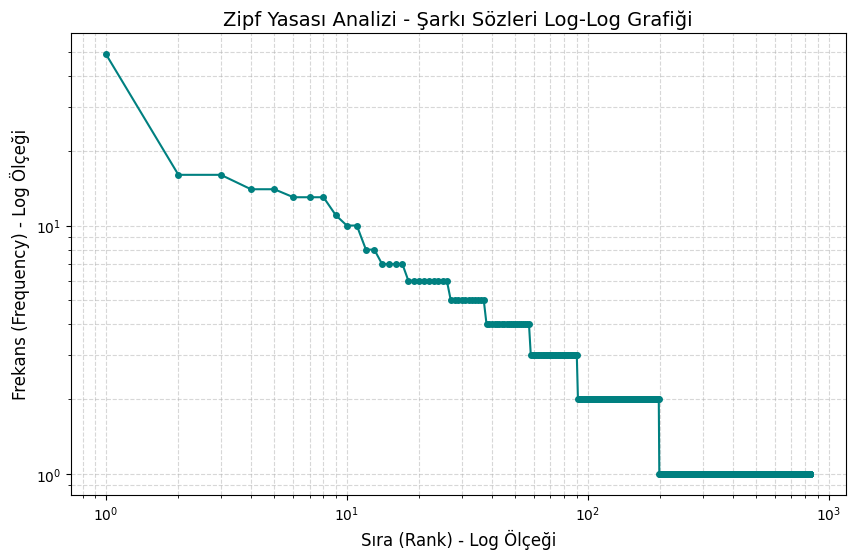

En sık geçen ilk 10 kelime ve frekansları:
[('bir', 49), ('gibi', 16), ('bu', 16), ('ben', 14), ('beni', 14), ('sen', 13), ('seni', 13), ('ne', 13), ('sana', 11), ('benim', 10)]


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from nltk.probability import FreqDist

try:
    df_ham = pd.read_csv('ham_veri_seti.csv')
    
    tum_metin = " ".join(df_ham['Ham_Soz'].astype(str).tolist()).lower()
    kelimeler = re.findall(r'\w+', tum_metin)

    frekanslar = FreqDist(kelimeler)
    sirali_frekanslar = sorted(frekanslar.values(), reverse=True)
    
    siralar = range(1, len(sirali_frekanslar) + 1)

    plt.figure(figsize=(10, 6))
    plt.loglog(siralar, sirali_frekanslar, marker="o", linestyle="-", color='teal', markersize=4)

    plt.title("Zipf Yasası Analizi - Şarkı Sözleri Log-Log Grafiği", fontsize=14)
    plt.xlabel("Sıra (Rank) - Log Ölçeği", fontsize=12)
    plt.ylabel("Frekans (Frequency) - Log Ölçeği", fontsize=12)
    plt.grid(True, which="both", ls="--", alpha=0.5)

    plt.show()

    print("En sık geçen ilk 10 kelime ve frekansları:")
    print(frekanslar.most_common(10))

except FileNotFoundError:
    print("🚨 HATA: 'ham_veri_seti.csv' bulunamadı! Lütfen önce Veri Yükleme hücresini çalıştırın.")

4. Ön İşleme (Pre-processing) Aşamaları
Bu bölümde, oluşturulan 55 şarkılık tam metin korpusu üzerinde modelleme öncesi gerekli olan temizlik ve standartlaştırma işlemleri hiyerarşik bir şekilde uygulanacaktır. Metin verilerinin gürültüden arındırılması, NLP modellerinin başarımı ve istatistiksel analizlerin tutarlılığı için kritik öneme sahiptir.

Her bir işlem adımında takip edilen teknik standartlar şunlardır:

Kütüphane Bildirimi: Uygulanan her metodun hangi kütüphane (NLTK, Re, TurkishStemmer vb.) aracılığıyla gerçekleştirildiği hem rapor metninde hem de kod blokları içerisinde açıklama satırı olarak belirtilmiştir.

Karşılaştırmalı Analiz (Önce/Sonra): Yapılan işlemin veri yapısını nasıl dönüştürdüğünü somut olarak gözlemlemek adına, her aşamada karşılaştırmalı çıktı tabloları sunulmuştur.

İşlem Akışı: Süreç; genel temizlik, normalizasyon (lowercasing), parçalama (tokenization) ve kelime köklerine indirgeme (stemming/lemmatization) sıralamasıyla, birbirini takip eden fonksiyonel bir yapıda kurgulanmıştır.

🛠️ Uygulanacak Temel NLP Teknikleri
Genel İçerik Temizliği: HTML etiketleri, sayılar ve özel sembollerin ayıklanması.

Lowercasing: Kelime bütünlüğünün sağlanması için tüm metnin küçük harfe dönüştürülmesi.

Tokenization: Metnin cümle ve kelime bazlı anlamlı parçalara ayrılması.

Stop Word Removal: "ve", "ama", "da" gibi bilgi değeri düşük ancak frekansı yüksek durak kelimelerin temizlenmesi.

Lemmatization & Stemming: Kelimelerin sözlük köklerine ve eklerinden arındırılmış gövdelerine indirgenmesi.

4.1 & 4.2 Genel Temizlik ve Küçük Harfe Çevirme (Lowercasing)
Metin ön işlemenin bu ilk adımında, HTML etiketleri, sayılar ve gereksiz semboller re kütüphanesi ile temizlenmiş, ardından tüm harfler küçük harfe dönüştürülmüştür. Bu işlem, modelin kelimeleri standart bir yapıda algılamasını sağlar ve "Merhaba" ile "merhaba" kelimelerinin aynı kabul edilmesini garantiler.

In [17]:
import re

def temizle(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s\.]', '', text)
    return text

df['Adim1_Temiz'] = df['Ham_Soz'].apply(temizle)
df['Adim2_KucukHarf'] = df['Adim1_Temiz'].apply(lambda x: x.lower())

print("--- ADIM 4.1 & 4.2: TEMİZLİK VE LOWERCASING ---")
display(df[['Ham_Soz', 'Adim2_KucukHarf']].head(3))

--- ADIM 4.1 & 4.2: TEMİZLİK VE LOWERCASING ---


,Ham_Soz,Adim2_KucukHarf
0,"Bugün benim doğum günüm, Hem sarhoşum hem yast...",bugün benim doğum günüm hem sarhoşum hem yasta...
1,"Kimseyi görmedim ben, Senden daha güzel. Kimse...",kimseyi görmedim ben senden daha güzel. kimsey...
2,"Gücün var mı sevgilim, Derin sularda inci tane...",gücün var mı sevgilim derin sularda inci tanes...


4.3 Kelimelere Ayırma (Tokenization)
Bu adımda, temizlenmiş metinler nltk kütüphanesi kullanılarak anlamlı yapı taşlarına (token) ayrılmıştır. İşlem sırasında cümle bütünlüğü korunarak modelin ileride bağlamı daha iyi anlaması hedeflenmiştir.

In [18]:
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize

def tokenize_et(text):
    sentences = sent_tokenize(text)
    tokenized_data = []
    for sent in sentences:
        tokens = word_tokenize(re.sub(r'[^\w\s]', '', sent))
        if tokens:
            tokenized_data.append(tokens)
    return tokenized_data

df['Adim3_Tokenize'] = df['Adim2_KucukHarf'].apply(tokenize_et)

print("\n--- ADIM 4.3: TOKENIZATION (Önce/Sonra) ---")
display(df[['Adim2_KucukHarf', 'Adim3_Tokenize']].head(3))


--- ADIM 4.3: TOKENIZATION (Önce/Sonra) ---


,Adim2_KucukHarf,Adim3_Tokenize
0,bugün benim doğum günüm hem sarhoşum hem yasta...,"[[bugün, benim, doğum, günüm, hem, sarhoşum, h..."
1,kimseyi görmedim ben senden daha güzel. kimsey...,"[[kimseyi, görmedim, ben, senden, daha, güzel]..."
2,gücün var mı sevgilim derin sularda inci tanes...,"[[gücün, var, mı, sevgilim, derin, sularda, in..."


4.4 Durak Kelimelerin Temizlenmesi (Stop Word Removal)
Bu aşamada, tek başına anlam ifade etmeyen ve modelde gürültü yaratabilecek sık kullanılan bağlaç ve edatlar (ve, ama, de vb.), nltk kütüphanesinin Türkçe durak kelimeler (stopwords) listesi kullanılarak metinden çıkarılmıştır.

In [19]:
from nltk.corpus import stopwords

durak_kelimeler = set(stopwords.words('turkish'))

def stopword_sil(token_lists):
    temiz_liste = []
    for cumle in token_lists:
        temiz_cumle = [kelime for kelime in cumle if kelime not in durak_kelimeler]
        if temiz_cumle:
            temiz_liste.append(temiz_cumle)
    return temiz_liste

df['Adim4_Stopwordsiz'] = df['Adim3_Tokenize'].apply(stopword_sil)

print("\n--- ADIM 4.4: STOP WORD REMOVAL (Önce/Sonra) ---")
display(df[['Adim3_Tokenize', 'Adim4_Stopwordsiz']].head(3))


--- ADIM 4.4: STOP WORD REMOVAL (Önce/Sonra) ---


,Adim3_Tokenize,Adim4_Stopwordsiz
0,"[[bugün, benim, doğum, günüm, hem, sarhoşum, h...","[[bugün, benim, doğum, günüm, sarhoşum, yastay..."
1,"[[kimseyi, görmedim, ben, senden, daha, güzel]...","[[kimseyi, görmedim, ben, senden, güzel], [kim..."
2,"[[gücün, var, mı, sevgilim, derin, sularda, in...","[[gücün, var, sevgilim, derin, sularda, inci, ..."


4.5 & 4.6 Kök Bulma (Lemmatization ve Stemming)
Metin ön işlemenin son aşamasında kelimeler formolojik olarak basitleştirilmiştir. WordNetLemmatizer kullanılarak kelimelerin sözlük köküne (lemmatization) ulaşılmış, ardından TurkishStemmer kullanılarak kelimeler eklerinden tamamen arındırılıp gövdelerine (stemming) indirgenmiştir.

In [20]:
from nltk.stem import WordNetLemmatizer
from TurkishStemmer import TurkishStemmer

lemmatizer = WordNetLemmatizer()
stemmer = TurkishStemmer()

def lemma_uygula(token_lists):
    return [[lemmatizer.lemmatize(k) for k in cumle] for cumle in token_lists]

def stem_uygula(token_lists):
    return [[stemmer.stem(k) for k in cumle] for cumle in token_lists]

df['Adim5_Lemmatized'] = df['Adim4_Stopwordsiz'].apply(lemma_uygula)
df['Adim6_Stemmed'] = df['Adim4_Stopwordsiz'].apply(stem_uygula)

print("\n--- ADIM 4.5 & 4.6: LEMMATIZATION & STEMMING (Karşılaştırmalı) ---")
display(df[['Adim4_Stopwordsiz', 'Adim5_Lemmatized', 'Adim6_Stemmed']].head(3))


--- ADIM 4.5 & 4.6: LEMMATIZATION & STEMMING (Karşılaştırmalı) ---


,Adim4_Stopwordsiz,Adim5_Lemmatized,Adim6_Stemmed
0,"[[bugün, benim, doğum, günüm, sarhoşum, yastay...","[[bugün, benim, doğum, günüm, sarhoşum, yastay...","[[bugü, ben, dok, gün, sarhoş, yas], [bir, bar..."
1,"[[kimseyi, görmedim, ben, senden, güzel], [kim...","[[kimseyi, görmedim, ben, senden, güzel], [kim...","[[kimse, görm, ben, sen, güzel], [kimse, tan, ..."
2,"[[gücün, var, sevgilim, derin, sularda, inci, ...","[[gücün, var, sevgilim, derin, sularda, inci, ...","[[güç, var, sevgil, der, su, inç, tane, arama]..."


5. Çıktıların Kaydedilmesi
Tüm ön işleme adımları başarıyla tamamlandıktan sonra, yönerge beklentilerine uygun olarak elde edilen Stemmed ve Lemmatized veri setleri projenin sonraki aşamalarında (modelleme) kullanılmak üzere CSV formatında dışa aktarılmıştır.

In [21]:
df_stemmed = df[['Sarkici_Adi', 'Sarki_Adi', 'Besteci', 'Yil', 'Adim6_Stemmed']]
df_stemmed.to_csv('stemmed_veri_seti.csv', index=False, encoding='utf-8')

df_lemmatized = df[['Sarkici_Adi', 'Sarki_Adi', 'Besteci', 'Yil', 'Adim5_Lemmatized']]
df_lemmatized.to_csv('lemmatized_veri_seti.csv', index=False, encoding='utf-8')

print("\n✅ Ön işleme adımları yönergeye uygun olarak hatasız tamamlandı.")
print("✅ 'stemmed_veri_seti.csv' ve 'lemmatized_veri_seti.csv' dosyaları kaydedildi!")


✅ Ön işleme adımları yönergeye uygun olarak hatasız tamamlandı.
✅ 'stemmed_veri_seti.csv' ve 'lemmatized_veri_seti.csv' dosyaları kaydedildi!
